# Install Qiskit and co.

In [1]:
print("Installing dependencies... ")
!pip install -q qiskit[all]
# for drawing circuits using matplotlib:
!pip install -q pylatexenc
# # for simulation via ibm:
!pip install -q qiskit_ibm_runtime
print("Completed.")

Installing dependencies... 
Completed.


In [2]:
import qiskit, qiskit_ibm_runtime
print(f"qiskit = {qiskit.version.get_version_info()}") # 2.0.0
print(f"qiskit_ibm_runtime = {qiskit_ibm_runtime.version.get_version_info()}") # 0.38.0

qiskit = 2.3.0
qiskit_ibm_runtime = 0.45.1


# Create and Draw a Quantum Circuit

In [3]:
from qiskit import QuantumCircuit

In [4]:
# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)

# Return a drawing of the circuit using text (useful for running in terminal).
qc.draw()

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

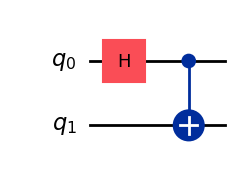

In [5]:
# Return a drawing of the circuit using MatPlotLib/LaTeX.
# 'text' | 'mpl' | 'latex' (LaTeX is needed) | 'latex_source'
qc.draw('mpl')

# Parametric and Controlled Quantum Gates

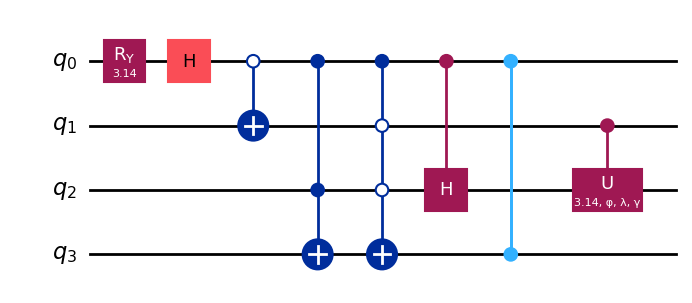

In [6]:
from qiskit.circuit import Parameter
theta = Parameter('θ')
pqc = QuantumCircuit(4)
pqc.ry(theta, 0)
pqc.h(0)
pqc.cx(0,1, ctrl_state='0')
pqc.ccx(0,2,3)
pqc.mcx([0,1,2],3,ctrl_state='001')
pqc.ch(0,2)
pqc.cz(0,3)

phi = Parameter('φ')
lam = Parameter('λ')
gamma = Parameter('γ')
pqc.cu(theta, phi, lam, gamma, 1,2)

pqc.assign_parameters({theta: 3.14159}, inplace=True)
pqc.draw("mpl")

# Statevector Simulation

In [7]:
from qiskit.quantum_info import Statevector

In [8]:
# Set the initial state of the system
psi = Statevector.from_label("00")
# or psi = Statevector([1,0,0,0])

# Evolve the state by the quantum circuit
psi = psi.evolve(qc)
psi #or state.data -> np array

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [9]:
# 'text' | 'latex' | 'latex_source' | 'qsphere' | 'hinton' | 'bloch' | 'city' | 'paulivec'
psi.draw('latex')

<IPython.core.display.Latex object>

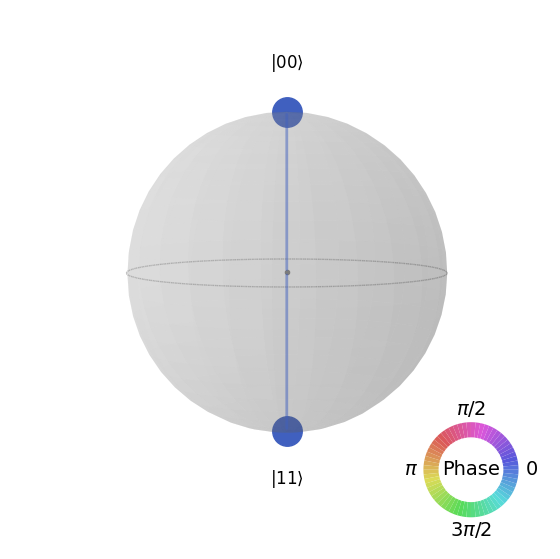

In [10]:
psi.draw('qsphere')

# Unitary Matrix for the Circuit

In [11]:
from qiskit.quantum_info import Operator

U = Operator(qc)

# Show the results
U #or U.data -> np array

Operator([[ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j,
            0.        +0.j],
          [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
           -0.70710678+0.j],
          [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
            0.70710678+0.j],
          [ 0.70710678+0.j, -0.70710678+0.j,  0.        +0.j,
            0.        +0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [12]:
# 'text' | 'latex' | 'latex_source'
U.draw('latex')

<IPython.core.display.Latex object>

In [13]:
Z = Operator([[1,0],[0,-1]])
Z.draw('latex')

<IPython.core.display.Latex object>

# Measurement using Sampler

In [14]:
psi.draw('latex')

<IPython.core.display.Latex object>

In [15]:
# computational basis measurement probabilities
print(psi.probabilities())

[0.5 0.  0.  0.5]


In [16]:
# probability of getting some state phi using Born rule
phi = Statevector.from_label("++")
abs(phi.inner(psi))**2

np.float64(0.4999999999999998)

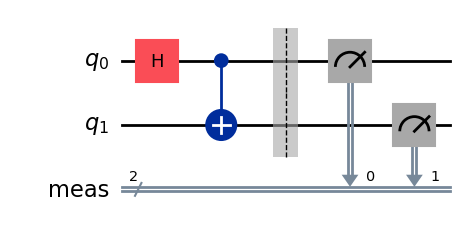

In [17]:
# Measure all qubits and store the results in a classical register
qc.measure_all()
qc.draw('mpl')

In [18]:
# Create a sampler to simulate computational basis measurement
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

# Simulate running the circuit 1024 times (default) to get probability dist.
# `qc` is entered as a list because sample can run multiple circuits,
# each of them will be run 1024 times. Here we are only running one circuit.
job = sampler.run([qc], shots=1024)
print(f"Job id: {job.job_id()}")

Job id: fd731083-d9b8-4151-bdba-83a4bfc71cb4


In [19]:
# Grab the result of the circuit at index 0 from the job.
result = job.result()[0]

# classical reg that stores the measurement data
for creg, data in result.data.items():
  counts = data.get_counts()
  print(f"{creg}: {counts}")

meas: {'00': 499, '11': 525}


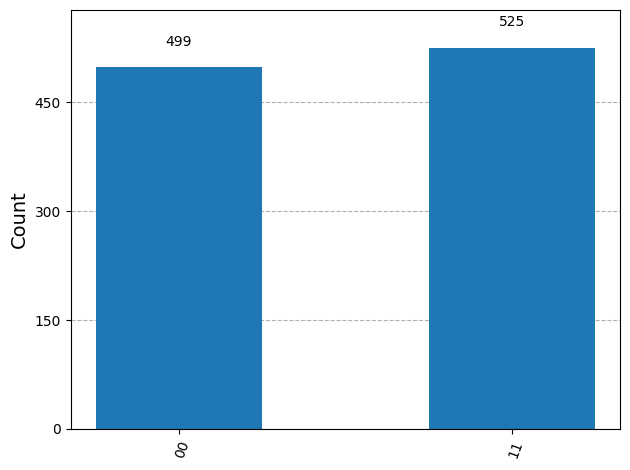

In [20]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

# Measurement in a Different Basis

# Registers

In [21]:
# Let's implement Deutsch-Jozsa (DJ) algorithm
# It returns all 0's if function is constant
import random, math
# dim: bit length of input to function
# prob_const: probability of getting a constant function
def generate_balanced_or_constant_function(dim, prob_const=None):
  if not prob_const: # all 0's, all 1's and all balanced
    prob_const = 2/(2 + math.comb(dim,dim//2))
  is_gen_const = random.choices([True, False],
                                weights=[prob_const, 1-prob_const])[0]
  if is_gen_const:# constant
    return [random.randint(0,1)]*dim
  else:
    balanced_func = [0]*(dim//2) + [1]*(dim//2)
    random.shuffle(balanced_func)
    return balanced_func

generate_balanced_or_constant_function(2**4)

[1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1]

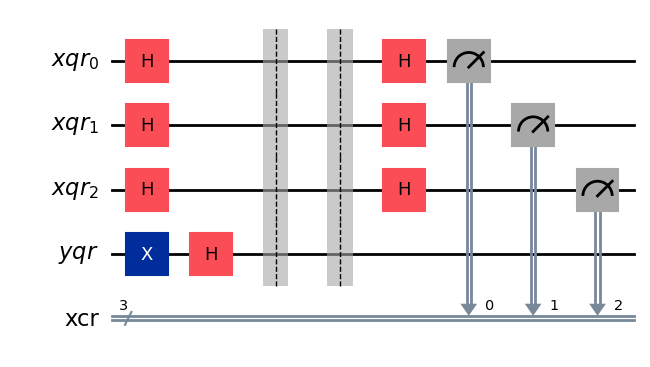

In [22]:
# You may use quantum and classical registers, and name them.
from qiskit import QuantumRegister, ClassicalRegister

# oracle generation
n = 3
f = generate_balanced_or_constant_function(2**n, 1)

# Create circuit with 2 quantum registers and 1 classical register
x_qreg = QuantumRegister(n, 'xqr')
y_qreg = QuantumRegister(1, 'yqr')
x_creg = ClassicalRegister(n, 'xcr')
dj = QuantumCircuit(x_qreg,y_qreg,x_creg)

# Construct circuit for DJ algorithm
dj.h(x_qreg) # notice it applies H gate to each qubit in x register
# create |-> state by applying HX on zero state
dj.x(y_qreg)
dj.h(y_qreg)
dj.barrier()
# query oracle (inside box)
# with dj.box():
for x,fx in enumerate(f):
  if fx:
    dj.mcx(x_qreg,y_qreg,ctrl_state=x)
dj.barrier()
# remaining part of DJ algo
dj.h(x_qreg)
dj.measure(x_qreg, x_creg)

dj.draw('mpl')

In [23]:
sampler = StatevectorSampler()
job = sampler.run([dj])
print(f"Job id: {job.job_id()}")

result = job.result()[0]
counts = result.data.xcr.get_counts()
print(f"Counts: {counts}")

# if we get all 0s every shot, 100% of the times, then const
all_0s_count = counts.get('0'*n,0)
is_const_func = all_0s_count == result.data.xcr.num_shots
print(f"Output: {'Constant' if is_const_func else 'Balanced'}")

# reveal oracle
print(f"Oracle: {f}")

Job id: f767c6cc-fdb1-4268-bb3b-6e8456ab4978
Counts: {'000': 1024}
Output: Constant
Oracle: [0, 0, 0, 0, 0, 0, 0, 0]


# Observables and Expectation value calculation


In [24]:
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparseObservable, SparsePauliOp

observables = [
    SparsePauliOp.from_sparse_observable(SparseObservable("000I"))
]
estimator = StatevectorEstimator()
dj.remove_final_measurements()
job = estimator.run([(dj,observables)])
print(f"Job id: {job.job_id()}")

result = job.result()[0]
print(f"Expected value: {result.data.evs[0]:0.3f}")

Job id: 8dffc650-4bb7-4758-a981-a45bd584c062
Expected value: 0.500


# Noise Simulation

In [25]:
qc = QuantumCircuit(1)
